# 🛒 Sales Data Analysis Project
## Tools: SQL + Python | pandas | matplotlib | seaborn
### Author: Mohammed Taqi Uddin | Date: 2nd March 2026

---

## 📌 Project Overview
This project analyzes sales data across different categories, products and months.
The goal is to extract business insights using SQL queries and Python visualizations.

**Key Questions Answered:**
- Which category generates the most sales and profit?
- What are the top performing products?
- Which months have highest sales?
- Which products are above average performers?

In [3]:
# ================================================
# PROJECT 1: SALES DATA ANALYSIS
# Tools: SQL + Python (Pandas + Seaborn)
# Author: Mohammed Taqi Uddin Faraz
# Date:  2nd March 2026
# ================================================


In [61]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

# Verify database connection
print("Tables in database:")
cursor.execute("SELECT name FROM sqlite_master WHERE type='table'")
print(cursor.fetchall())

sns.set_theme(style='whitegrid', palette='Set2')

print("All libraries loaded! ✅")

Tables in database:
[('Sales',)]
All libraries loaded! ✅


In [5]:
# Create SQLite database in memory
conn = sqlite3.connect(':memory:')
cursor = conn.cursor()

# Create Sales table
cursor.execute('''
    CREATE TABLE Sales (
        Order_ID INTEGER,
        Month TEXT,
        Category TEXT,
        Product TEXT,
        Sales INTEGER,
        Profit INTEGER,
        Quantity INTEGER
    )
''')

# Insert data
data = [
    (1,'Jan','Electronics','Laptop',1200,300,2),
    (2,'Feb','Clothing','Shirt',450,80,5),
    (3,'Mar','Electronics','Phone',800,150,3),
    (4,'Apr','Furniture','Chair',300,60,1),
    (5,'May','Clothing','Jeans',150,30,4),
    (6,'Jun','Electronics','Tablet',600,120,2),
    (7,'Jul','Furniture','Desk',450,90,1),
    (8,'Aug','Clothing','Jacket',200,40,3),
    (9,'Sep','Electronics','Headphones',180,35,5),
    (10,'Oct','Furniture','Sofa',900,180,1),
    (11,'Nov','Clothing','T-Shirt',120,25,6),
    (12,'Dec','Electronics','Monitor',700,140,2),
    (13,'Jan','Furniture','Bookshelf',350,70,1),
    (14,'Feb','Clothing','Trousers',130,28,4),
    (15,'Mar','Electronics','Smartwatch',250,50,3),
    (16,'Apr','Furniture','Table',480,95,1),
    (17,'May','Clothing','Sweater',170,35,5),
    (18,'Jun','Electronics','Earbuds',90,18,4),
    (19,'Jul','Furniture','Wardrobe',520,100,1),
    (20,'Aug','Clothing','Shorts',110,22,6)
]

cursor.executemany('INSERT INTO Sales VALUES (?,?,?,?,?,?,?)', data)
conn.commit()
print("Database created! ✅")

Database created! ✅


---
## 📊 Analysis 1: Sales by Category

**Objective:** Identify which category generates the most revenue and profit.

**SQL Used:** GROUP BY, SUM, COUNT

In [7]:
# SQL Query 1 - Total Sales by Category
query1 = '''
    SELECT Category, 
           SUM(Sales) as Total_Sales,
           SUM(Profit) as Total_Profit,
           COUNT(*) as Total_Orders
    FROM Sales
    GROUP BY Category
    ORDER BY Total_Sales DESC
'''

df_category = pd.read_sql_query(query1, conn)
print("Query 1 - Sales by Category:")
df_category

Query 1 - Sales by Category:


,Category,Total_Sales,Total_Profit,Total_Orders
0,Electronics,3820,813,7
1,Furniture,3000,595,6
2,Clothing,1330,260,7


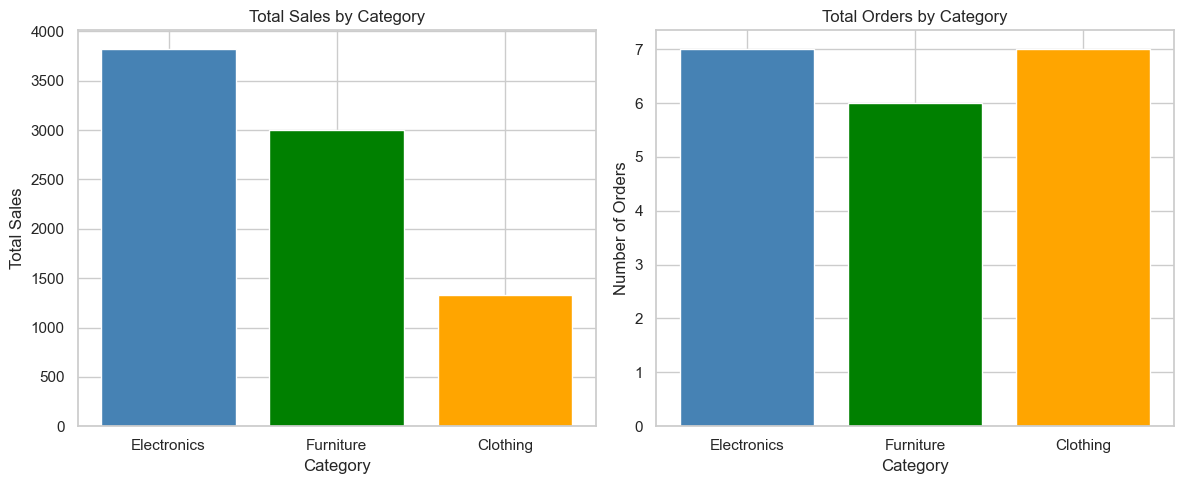

In [8]:
# Visualize Query 1 result
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Total Sales by Category
axes[0].bar(df_category['Category'], df_category['Total_Sales'], color=['steelblue','green','orange'])
axes[0].set_title('Total Sales by Category')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Total Sales')

# Total Orders by Category
axes[1].bar(df_category['Category'], df_category['Total_Orders'], color=['steelblue','green','orange'])
axes[1].set_title('Total Orders by Category')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Number of Orders')

plt.tight_layout()
plt.savefig('category_analysis.png', dpi=150)
plt.show()

### 💡 Insight 1:
- **Electronics** dominates with **$3,820** in total sales
- Despite equal order counts, Electronics generates **3x more revenue** than Clothing
- **Clothing** has the lowest profit at only **$260**

---
## 📊 Analysis 2: Top 5 Products

**Objective:** Find the best performing products by sales and profit margin.

**SQL Used:** ORDER BY, LIMIT, ROUND, CAST

In [11]:
# SQL Query 2 - Top 5 Products by Sales
query2 = '''
    SELECT Product,
           Category,
           Sales,
           Profit,
           ROUND(CAST(Profit AS FLOAT) / Sales * 100, 2) as Profit_Margin
    FROM Sales
    ORDER BY Sales DESC
    LIMIT 5
'''

df_top5 = pd.read_sql_query(query2, conn)
print("Query 2 - Top 5 Products:")
df_top5

Query 2 - Top 5 Products:


,Product,Category,Sales,Profit,Profit_Margin
0,Laptop,Electronics,1200,300,25.00
1,Sofa,Furniture,900,180,20.00
2,Phone,Electronics,800,150,18.75
3,Monitor,Electronics,700,140,20.00
4,Tablet,Electronics,600,120,20.00


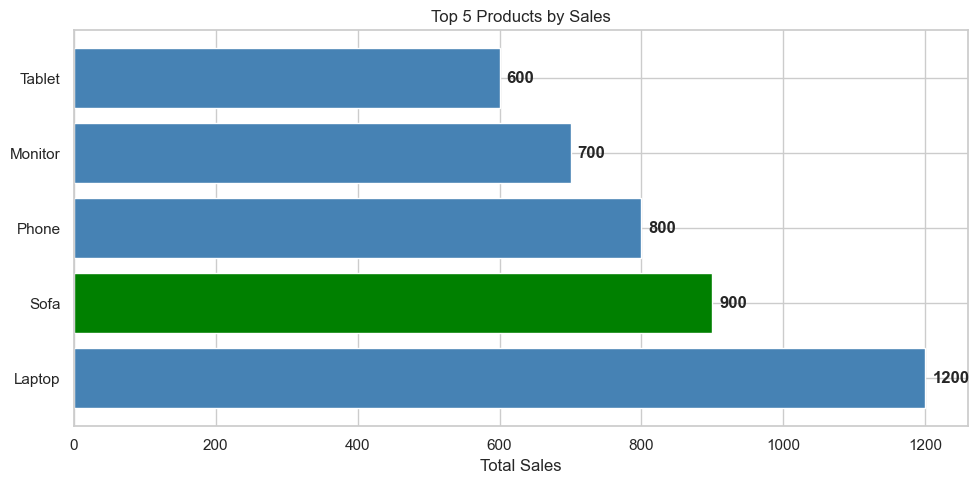

In [12]:
# Visualize Query 2 - Top 5 Products
plt.figure(figsize=(10,5))
colors = ['steelblue' if c == 'Electronics' else 'green' if c == 'Furniture' else 'orange' 
          for c in df_top5['Category']]

plt.barh(df_top5['Product'], df_top5['Sales'], color=colors)
plt.title('Top 5 Products by Sales')
plt.xlabel('Total Sales')

# Add value labels on bars
for i, v in enumerate(df_top5['Sales']):
    plt.text(v + 10, i, str(v), va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('top5_products.png', dpi=150)
plt.show()

### 💡 Insight 2:
- **Laptop** is the star product with **$1,200** sales and **25% profit margin**
- **4 out of 5** top products are Electronics
- **Sofa** is the only non-Electronics product in top 5

---
## 📊 Analysis 3: Monthly Sales Trend

**Objective:** Identify which months have highest and lowest sales.

**SQL Used:** GROUP BY, SUM, ORDER BY

In [15]:
# SQL Query 3 - Monthly Sales Trend
query3 = '''
    SELECT Month,
           SUM(Sales) as Total_Sales,
           SUM(Profit) as Total_Profit
    FROM Sales
    GROUP BY Month
    ORDER BY Total_Sales DESC
'''

df_monthly = pd.read_sql_query(query3, conn)
print("Query 3 - Monthly Trend:")
df_monthly

Query 3 - Monthly Trend:


,Month,Total_Sales,Total_Profit
0,Jan,1550,370
1,Mar,1050,200
2,Jul,970,190
3,Oct,900,180
4,Apr,780,155
5,Dec,700,140
6,Jun,690,138
7,Feb,580,108
8,May,320,65
9,Aug,310,62


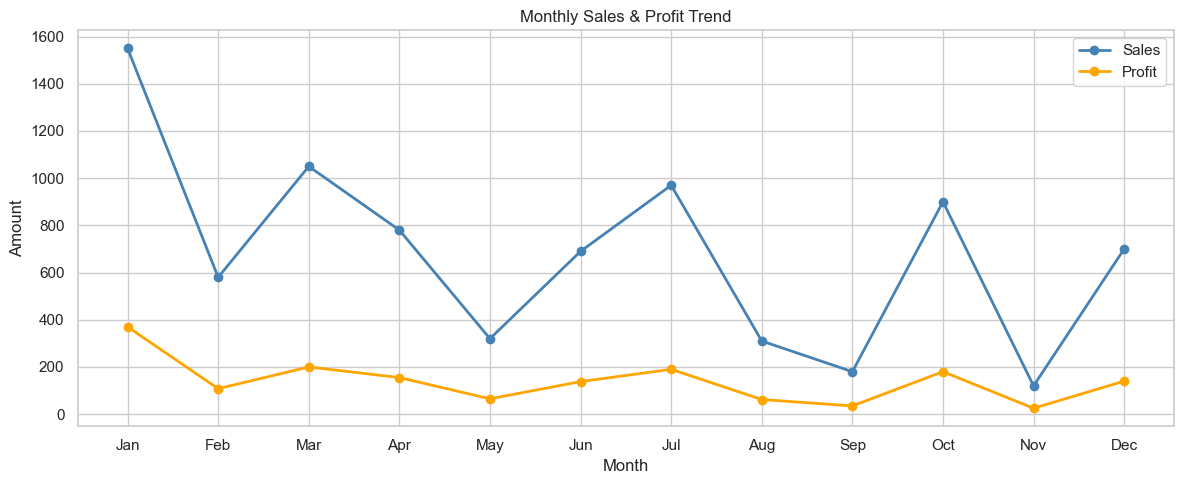

In [16]:
# Visualize Query 3 - Monthly Trend with 2 lines
month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
df_monthly_sorted = df_monthly.set_index('Month').reindex(month_order).reset_index()

plt.figure(figsize=(12,5))

# Sales line
plt.plot(df_monthly_sorted['Month'], df_monthly_sorted['Total_Sales'], 
         marker='o', color='steelblue', linewidth=2, label='Sales')

# Profit line
plt.plot(df_monthly_sorted['Month'], df_monthly_sorted['Total_Profit'], 
         marker='o', color='orange', linewidth=2, label='Profit')

plt.title('Monthly Sales & Profit Trend')
plt.xlabel('Month')
plt.ylabel('Amount')
plt.legend()
plt.tight_layout()
plt.savefig('monthly_trend.png', dpi=150)
plt.show()

### 💡 Insight 3:
- **January** has the highest sales at **$1,550**
- Clear **downward trend** from Jan to Nov
- **Q1 (Jan-Mar)** is the strongest quarter

---
## 📊 Analysis 4: Product Performance Rating

**Objective:** Classify products into High, Mid and Low performers.

**SQL Used:** CASE WHEN

In [19]:
# SQL Query 4 - Category Performance Rating using CASE WHEN
query4 = '''
    SELECT Product,
           Category,
           Sales,
           CASE 
               WHEN Sales >= 800 THEN 'High Performer'
               WHEN Sales >= 400 THEN 'Mid Performer'
               ELSE 'Low Performer'
           END as Performance
    FROM Sales
    ORDER BY Sales DESC
'''

df_performance = pd.read_sql_query(query4, conn)
print("Query 4 - Performance Rating:")
df_performance

Query 4 - Performance Rating:


,Product,Category,Sales,Performance
0,Laptop,Electronics,1200,High Performer
1,Sofa,Furniture,900,High Performer
2,Phone,Electronics,800,High Performer
3,Monitor,Electronics,700,Mid Performer
4,Tablet,Electronics,600,Mid Performer
5,Wardrobe,Furniture,520,Mid Performer
6,Table,Furniture,480,Mid Performer
7,Shirt,Clothing,450,Mid Performer
8,Desk,Furniture,450,Mid Performer
9,Bookshelf,Furniture,350,Low Performer


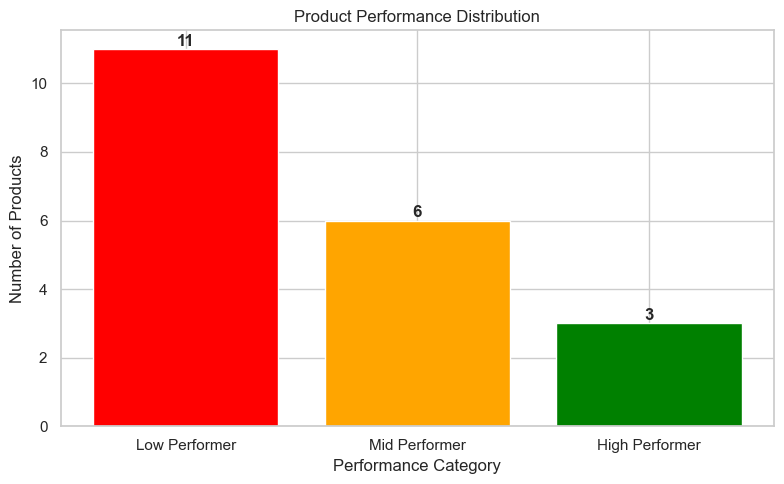

In [20]:
# Visualize Query 4 - Performance Distribution
performance_count = df_performance['Performance'].value_counts()

plt.figure(figsize=(8,5))
colors = ['red', 'orange', 'green']
plt.bar(performance_count.index, performance_count.values, color=colors)
plt.title('Product Performance Distribution')
plt.xlabel('Performance Category')
plt.ylabel('Number of Products')

# Add value labels on bars
for i, v in enumerate(performance_count.values):
    plt.text(i, v + 0.1, str(v), ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig('performance.png', dpi=150)
plt.show()

### 💡 Insight 4:
- Only **3 out of 20** products are High Performers
- **11 products** are Low Performers — majority of catalog underperforms
- Business should focus on promoting **Mid performers** to High

---
## 📊 Analysis 5: Profit Margin Analysis

**Objective:** Find which products are most profitable relative to their sales.

**SQL Used:** ROUND, CAST, WHERE

In [23]:
# SQL Query 5 - Best Profit Margin products
query5 = '''
    SELECT Product,
           Category,
           Sales,
           Profit,
           ROUND(CAST(Profit AS FLOAT) / Sales * 100, 2) as Profit_Margin
    FROM Sales
    WHERE Sales > 200
    ORDER BY Profit_Margin DESC
'''

df_margin = pd.read_sql_query(query5, conn)
print("Query 5 - Profit Margin Analysis:")
df_margin

Query 5 - Profit Margin Analysis:


,Product,Category,Sales,Profit,Profit_Margin
0,Laptop,Electronics,1200,300,25.00
1,Chair,Furniture,300,60,20.00
2,Tablet,Electronics,600,120,20.00
3,Desk,Furniture,450,90,20.00
4,Sofa,Furniture,900,180,20.00
5,Monitor,Electronics,700,140,20.00
6,Bookshelf,Furniture,350,70,20.00
7,Smartwatch,Electronics,250,50,20.00
8,Table,Furniture,480,95,19.79
9,Wardrobe,Furniture,520,100,19.23


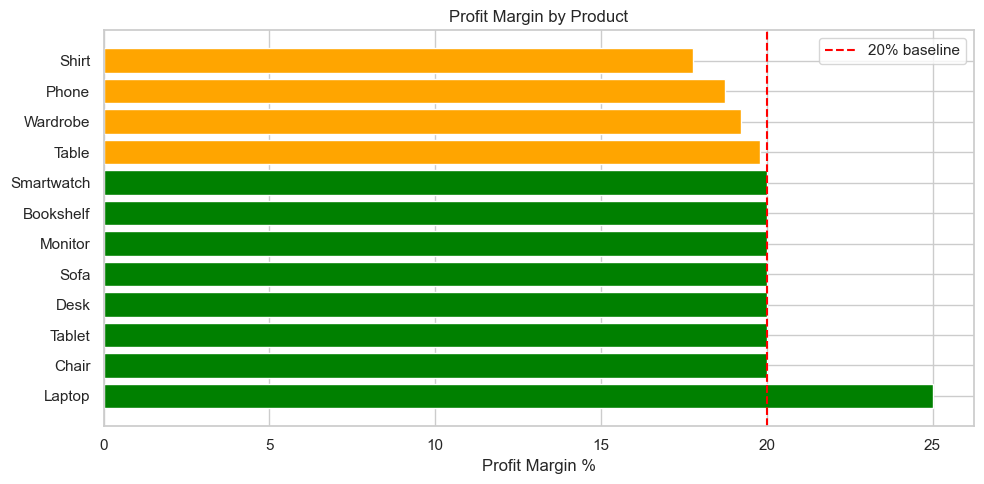

In [24]:
# Visualize Query 5 - Profit Margin
plt.figure(figsize=(10,5))
colors = ['green' if x >= 20 else 'orange' for x in df_margin['Profit_Margin']]
plt.barh(df_margin['Product'], df_margin['Profit_Margin'], color=colors)
plt.title('Profit Margin by Product')
plt.xlabel('Profit Margin %')
plt.axvline(x=20, color='red', linestyle='--', label='20% baseline')
plt.legend()
plt.tight_layout()
plt.savefig('profit_margin.png', dpi=150)
plt.show()

### 💡 Insight 5:
- **Laptop** has the best profit margin at **25%**
- Most products cluster around **20% margin**
- **Clothing** has the weakest margin at **17.78%**

---
## 📊 Analysis 6: Above Average Products

**Objective:** Find products that perform above the overall sales average.

**SQL Used:** Subquery, AVG

In [47]:
# SQL Query 6 - Products above average sales (Subquery)
query6 = '''
    SELECT Product,
           Category,
           Sales,
           Profit
    FROM Sales
    WHERE Sales > (SELECT AVG(Sales) FROM Sales)
    ORDER BY Sales DESC
'''

df_above_avg = pd.read_sql_query(query6, conn)

# Get real average from SQL
avg_sales = pd.read_sql_query('SELECT ROUND(AVG(Sales),0) as avg FROM Sales', conn)['avg'][0]
print(f"Average Sales: {avg_sales:.0f}")
print(f"Products above average: {len(df_above_avg)}")
df_above_avg

Average Sales: 408
Products above average: 9


,Product,Category,Sales,Profit
0,Laptop,Electronics,1200,300
1,Sofa,Furniture,900,180
2,Phone,Electronics,800,150
3,Monitor,Electronics,700,140
4,Tablet,Electronics,600,120
5,Wardrobe,Furniture,520,100
6,Table,Furniture,480,95
7,Shirt,Clothing,450,80
8,Desk,Furniture,450,90


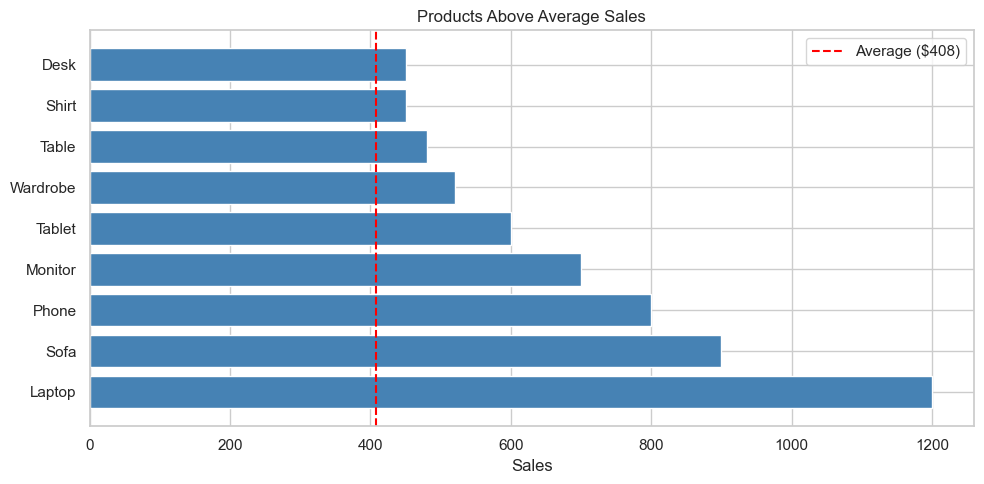

In [53]:
# Visualize Query 6 - Above Average Products
plt.figure(figsize=(10,5))
plt.barh(df_above_avg['Product'], df_above_avg['Sales'], color='steelblue')
plt.axvline(x=408, color='red', linestyle='--', label='Average ($408)')
plt.title('Products Above Average Sales')
plt.xlabel('Sales')
plt.legend()
plt.tight_layout()
plt.savefig('above_average.png', dpi=150)
plt.show()

### 💡 Insight 6:
- Only 9 out of 20 products are above average sales of $408
- Electronics and Furniture dominate above average list
- Clothing only has 1 product (Shirt at $450) above average
- Clothing is the weakest category overall

---
# 🏁 Project Summary

## Key Business Insights:

| Finding | Detail |
|---------|--------|
| Best Category | Electronics ($3,820 sales) |
| Best Product | Laptop ($1,200 sales, 25% margin) |
| Best Month | January ($1,550 sales) |
| Weakest Category | Clothing (lowest margin 17.78%) |
| Above Average Products | 9 out of 20 |
| High Performers | Only 3 out of 20 products |

## Skills Demonstrated:
- ✅ SQL: GROUP BY, JOINS, CASE WHEN, Subqueries
- ✅ Python: Pandas, Matplotlib, Seaborn
- ✅ Data Visualization: 6 different chart types
- ✅ Business Insights: Actionable recommendations